In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pymc.sampling_jax
import arviz as az
import xarray as xr
from numpy.polynomial.polynomial import Polynomial
import scipy.stats as stats
import warnings
from pymc import HalfCauchy, Model, Normal, sample

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In [3]:
size = 200 # numero di osservazioni nel campione
true_intercept = 1 # alpha
true_slope = 2 # beta

x = np.linspace(0, 1, size)
# y = a + b*x
true_regression_line = true_intercept + true_slope * x
# add noise
y = true_regression_line + rng.normal(scale=0.5, size=size) # sigma = 0.5

data = pd.DataFrame(dict(x=x, y=y))
data.head()

,x,y
0,0.000000,1.152359
1,0.005025,0.490058
2,0.010050,1.395326
3,0.015075,1.500433
4,0.020101,0.064683


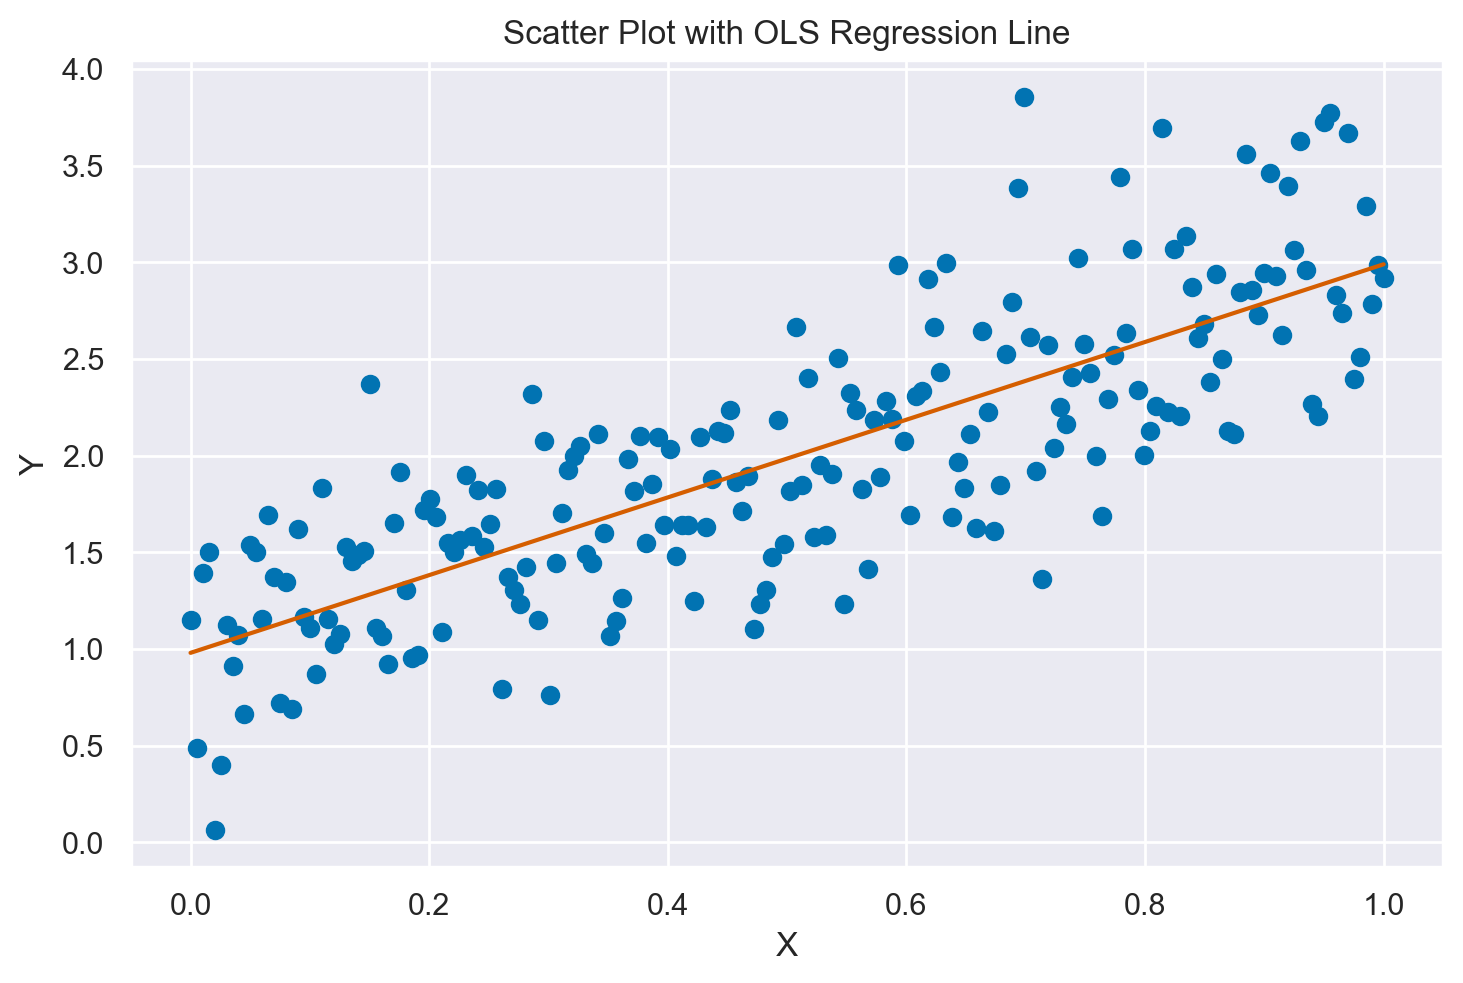

In [4]:
# Creating a scatter plot
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter Plot with OLS Regression Line")

# Fitting a linear regression
linear_regression = Polynomial.fit(data["x"], data["y"], 1)

# Plotting the regression line
plt.plot(data["x"], linear_regression(data["x"]), color="C3")
plt.show()

In [5]:
# Log-Gaussian likelihood 
def log_gaussian_likelihood(y, mu, sigma_squared):
    return stats.norm.logpdf(y, loc=mu, scale=np.sqrt(sigma_squared))

In [6]:
# Log-Gaussian prior
def log_gaussian_prior(param, mean=0, variance=1):
    return stats.norm.logpdf(param, loc=mean, scale=np.sqrt(variance))

In [7]:
# Log-Posterior calculation
def calc_log_posterior(a, b, y=y, x=x, sigma_squared=1.0):
    mu = a + b * x
    log_likelihood = log_gaussian_likelihood(y, mu, sigma_squared)
    log_prior_a = log_gaussian_prior(a)
    log_prior_b = log_gaussian_prior(b)
    return np.sum(log_likelihood) + log_prior_a + log_prior_b

In [8]:
# Brute-force grid search for posterior visualization
X1 = np.linspace(0, 3, 101)  # alpha (intercept)
X2 = np.linspace(0, 3, 100)  # beta (slope)
log_pp = np.zeros((101, 100))

k = 0
for x1 in X1:
    j = 0
    for x2 in X2:
        log_pp[k, j] = calc_log_posterior(x1, x2)
        j += 1
    k += 1

In [9]:
# To visualize in the original scale, we can exponentiate log_pp
pp = np.exp(log_pp - np.max(log_pp))  # Subtract the max for numerical stability

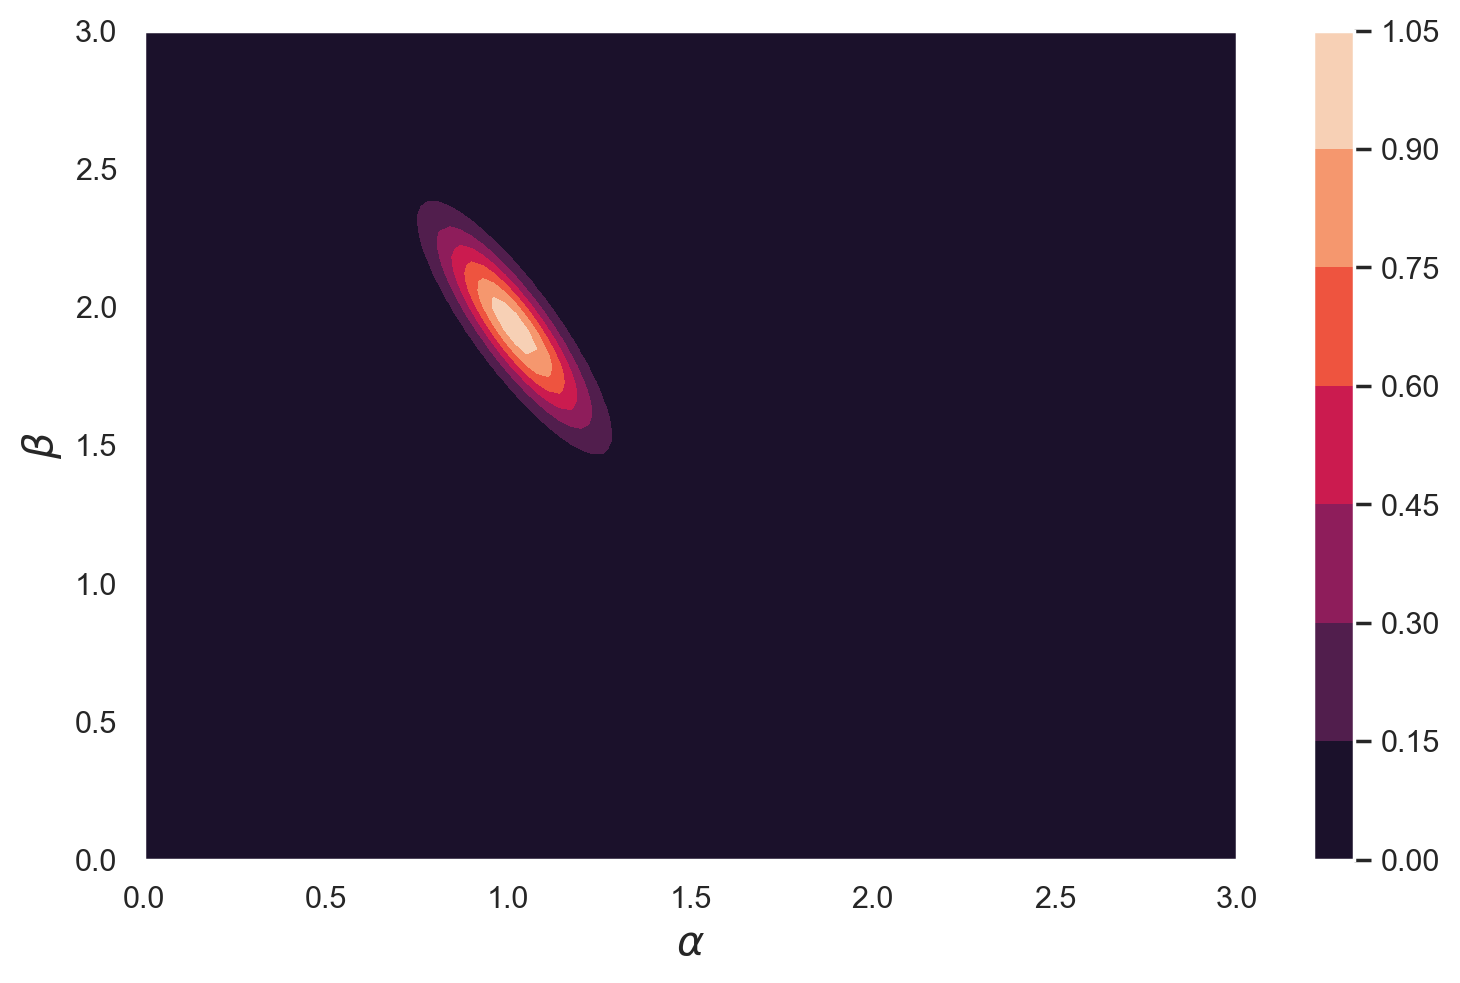

In [10]:
plt.contourf(X1, X2, pp.T)
plt.xlabel("$\\alpha$", size=15)
plt.ylabel("$\\beta$", size=15)
plt.colorbar()
plt.show()

In [11]:
with Model() as model:
    # Define priors
    alpha = pm.Normal("alpha", sigma=1)
    beta = pm.Normal("beta", sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=5)
    # Define likelihood
    pm.Normal("y_obs", mu=alpha + beta * x, sigma=sigma, observed=y)

In [12]:
with model:
    idata = pm.sampling_jax.sample_numpyro_nuts()

Compiling...


Compilation time = 0:00:01.738028


Sampling...


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling time = 0:00:02.622720


Transforming variables...


Transformation time = 0:00:00.117960


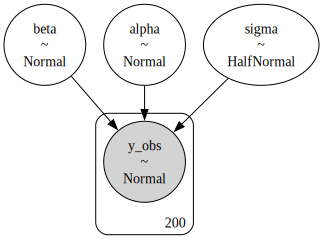

In [13]:
pm.model_to_graphviz(model)

In [14]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [15]:
idata.posterior["alpha"].shape

(4, 1000)

In [16]:
idata.posterior["alpha"][0, 0:5]

<xarray.DataArray 'alpha' (draw: 5)>
array([1.0346396 , 0.97481813, 1.0325388 , 1.0694342 , 1.04594352])
Coordinates:
    chain    int64 0
  * draw     (draw) int64 0 1 2 3 4

In [17]:
idata.posterior["alpha"][1, 0:5]

<xarray.DataArray 'alpha' (draw: 5)>
array([0.93819772, 1.01215996, 0.95441455, 1.02502487, 1.00666527])
Coordinates:
    chain    int64 1
  * draw     (draw) int64 0 1 2 3 4

In [18]:
idata.posterior["beta"].shape

(4, 1000)

In [19]:
data["x"].shape

(200,)

In [20]:
print(*data.x[0:5])

0.0 0.005025125628140704 0.010050251256281407 0.01507537688442211 0.020100502512562814


In [21]:
print(*y[0:5])

1.1523585398772156 0.4900581981360337 1.3953261004157915 1.5004331119644512 0.06468341069820738


In [22]:
print(idata.observed_data.y_obs[0:5].values)

[1.15235854 0.4900582  1.3953261  1.50043311 0.06468341]


In [23]:
idata.posterior["alpha"].mean().item()

0.9887213410199237

In [24]:
idata.posterior["beta"].mean().item()

1.9903389380511272

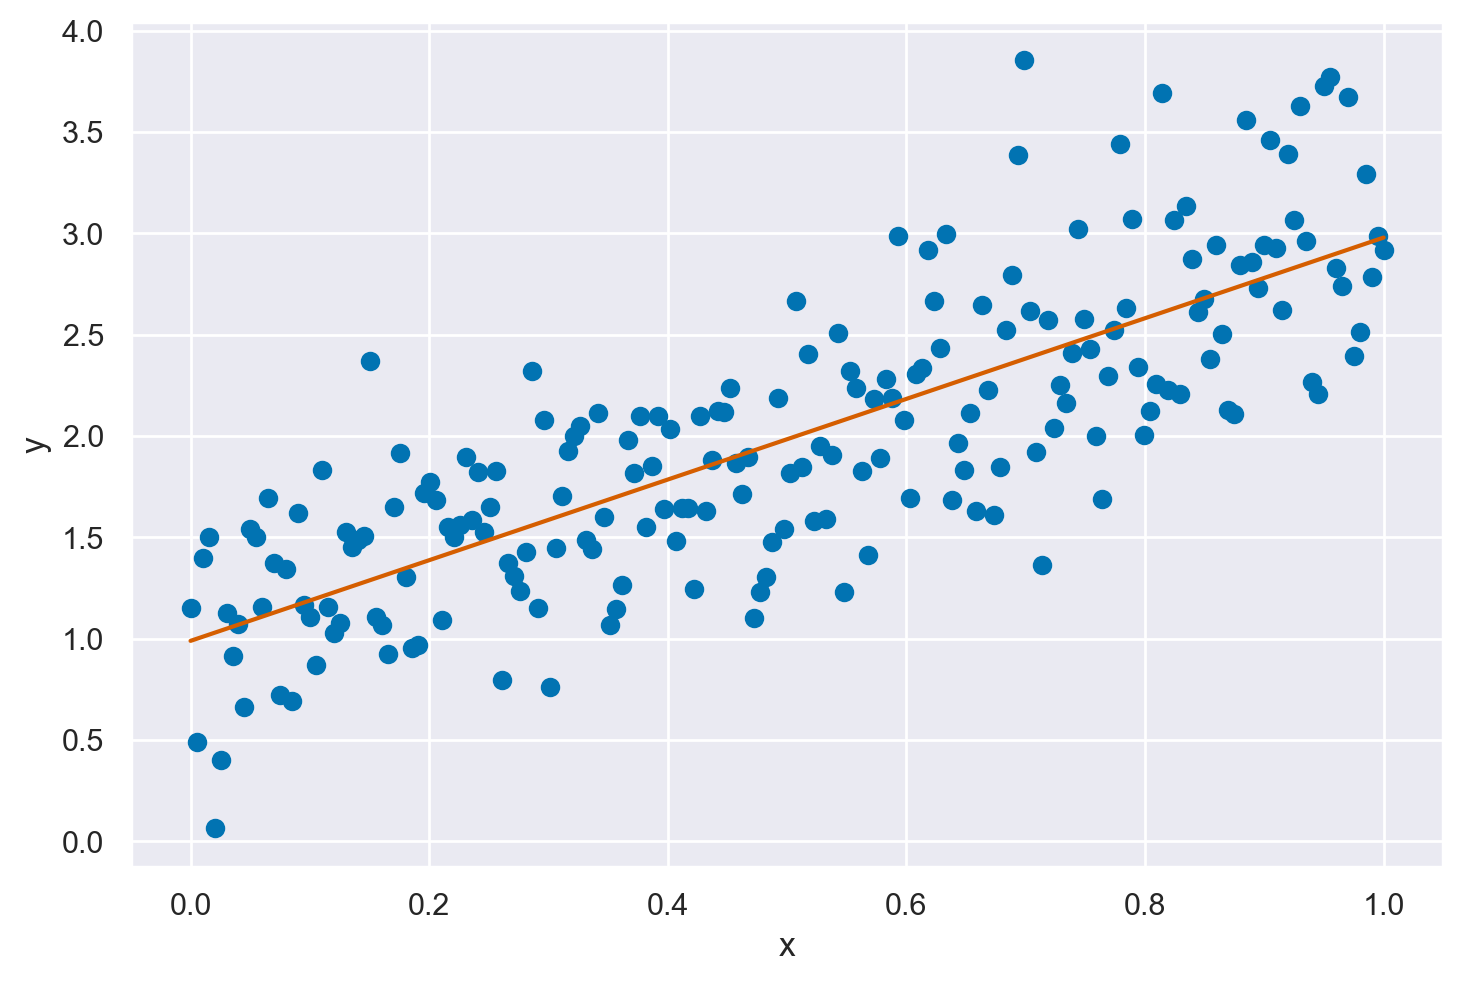

In [25]:
plt.plot(x, y, "C0o")
plt.plot(
    x,
    idata.posterior["alpha"].mean().item()
    + idata.posterior["beta"].mean().item() * x,
    "C3"
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [26]:
idata.posterior["y_model"] = idata.posterior["alpha"] + idata.posterior[
    "beta"
] * xr.DataArray(x)
idata.posterior["y_model"].shape

(4, 1000, 200)

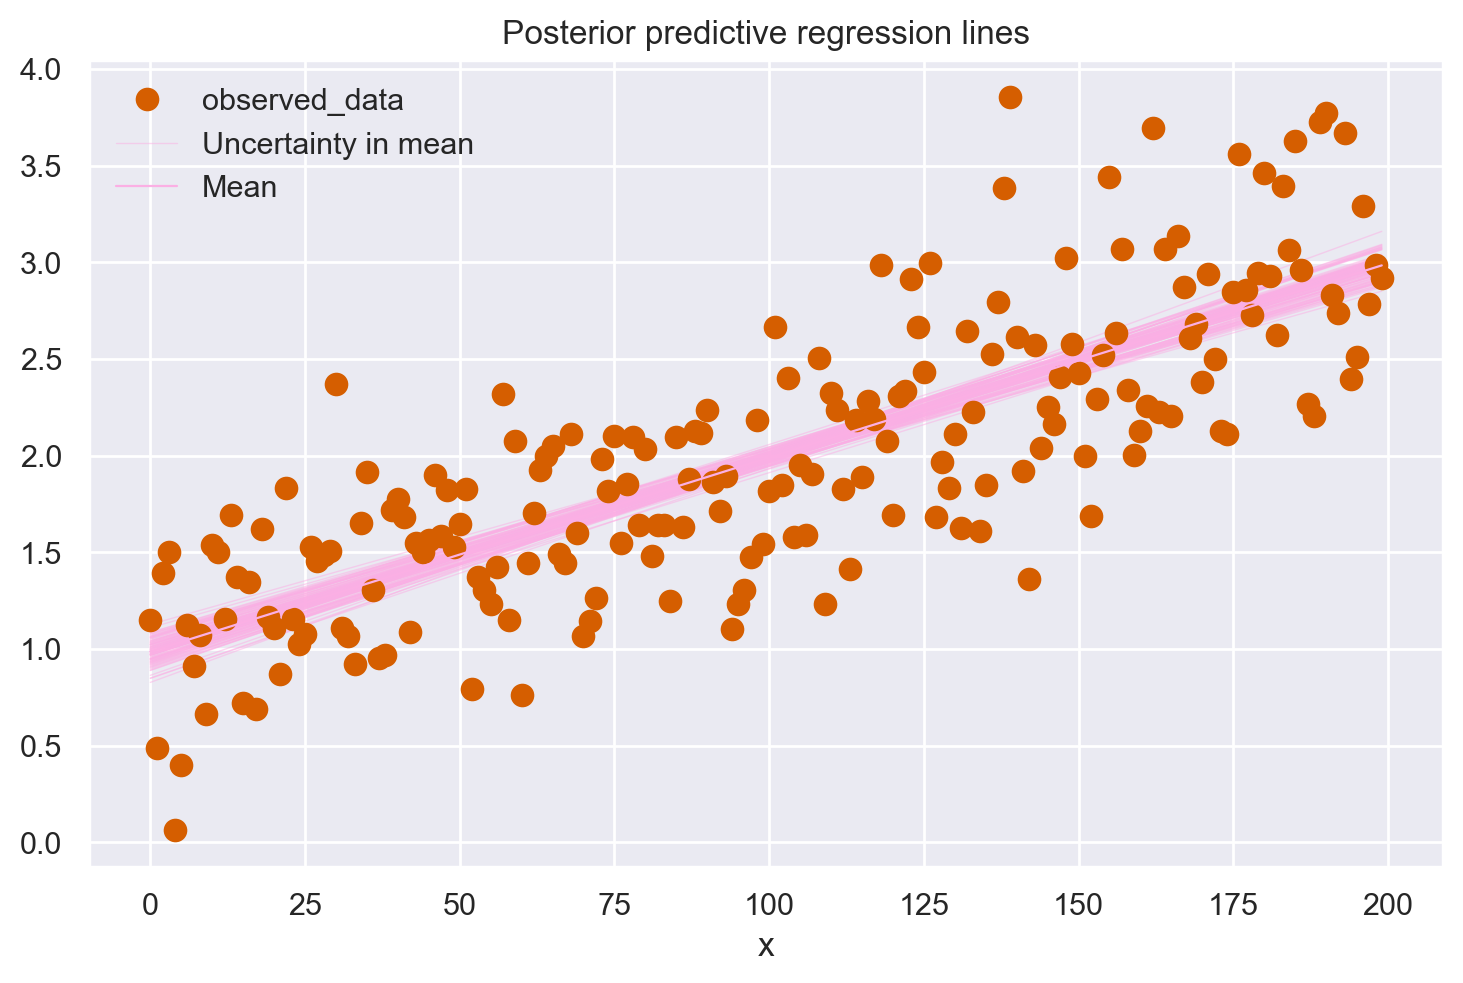

In [27]:
az.plot_lm(idata=idata, y=y, num_samples=100, y_model="y_model")
plt.title("Posterior predictive regression lines")
plt.xlabel("x");

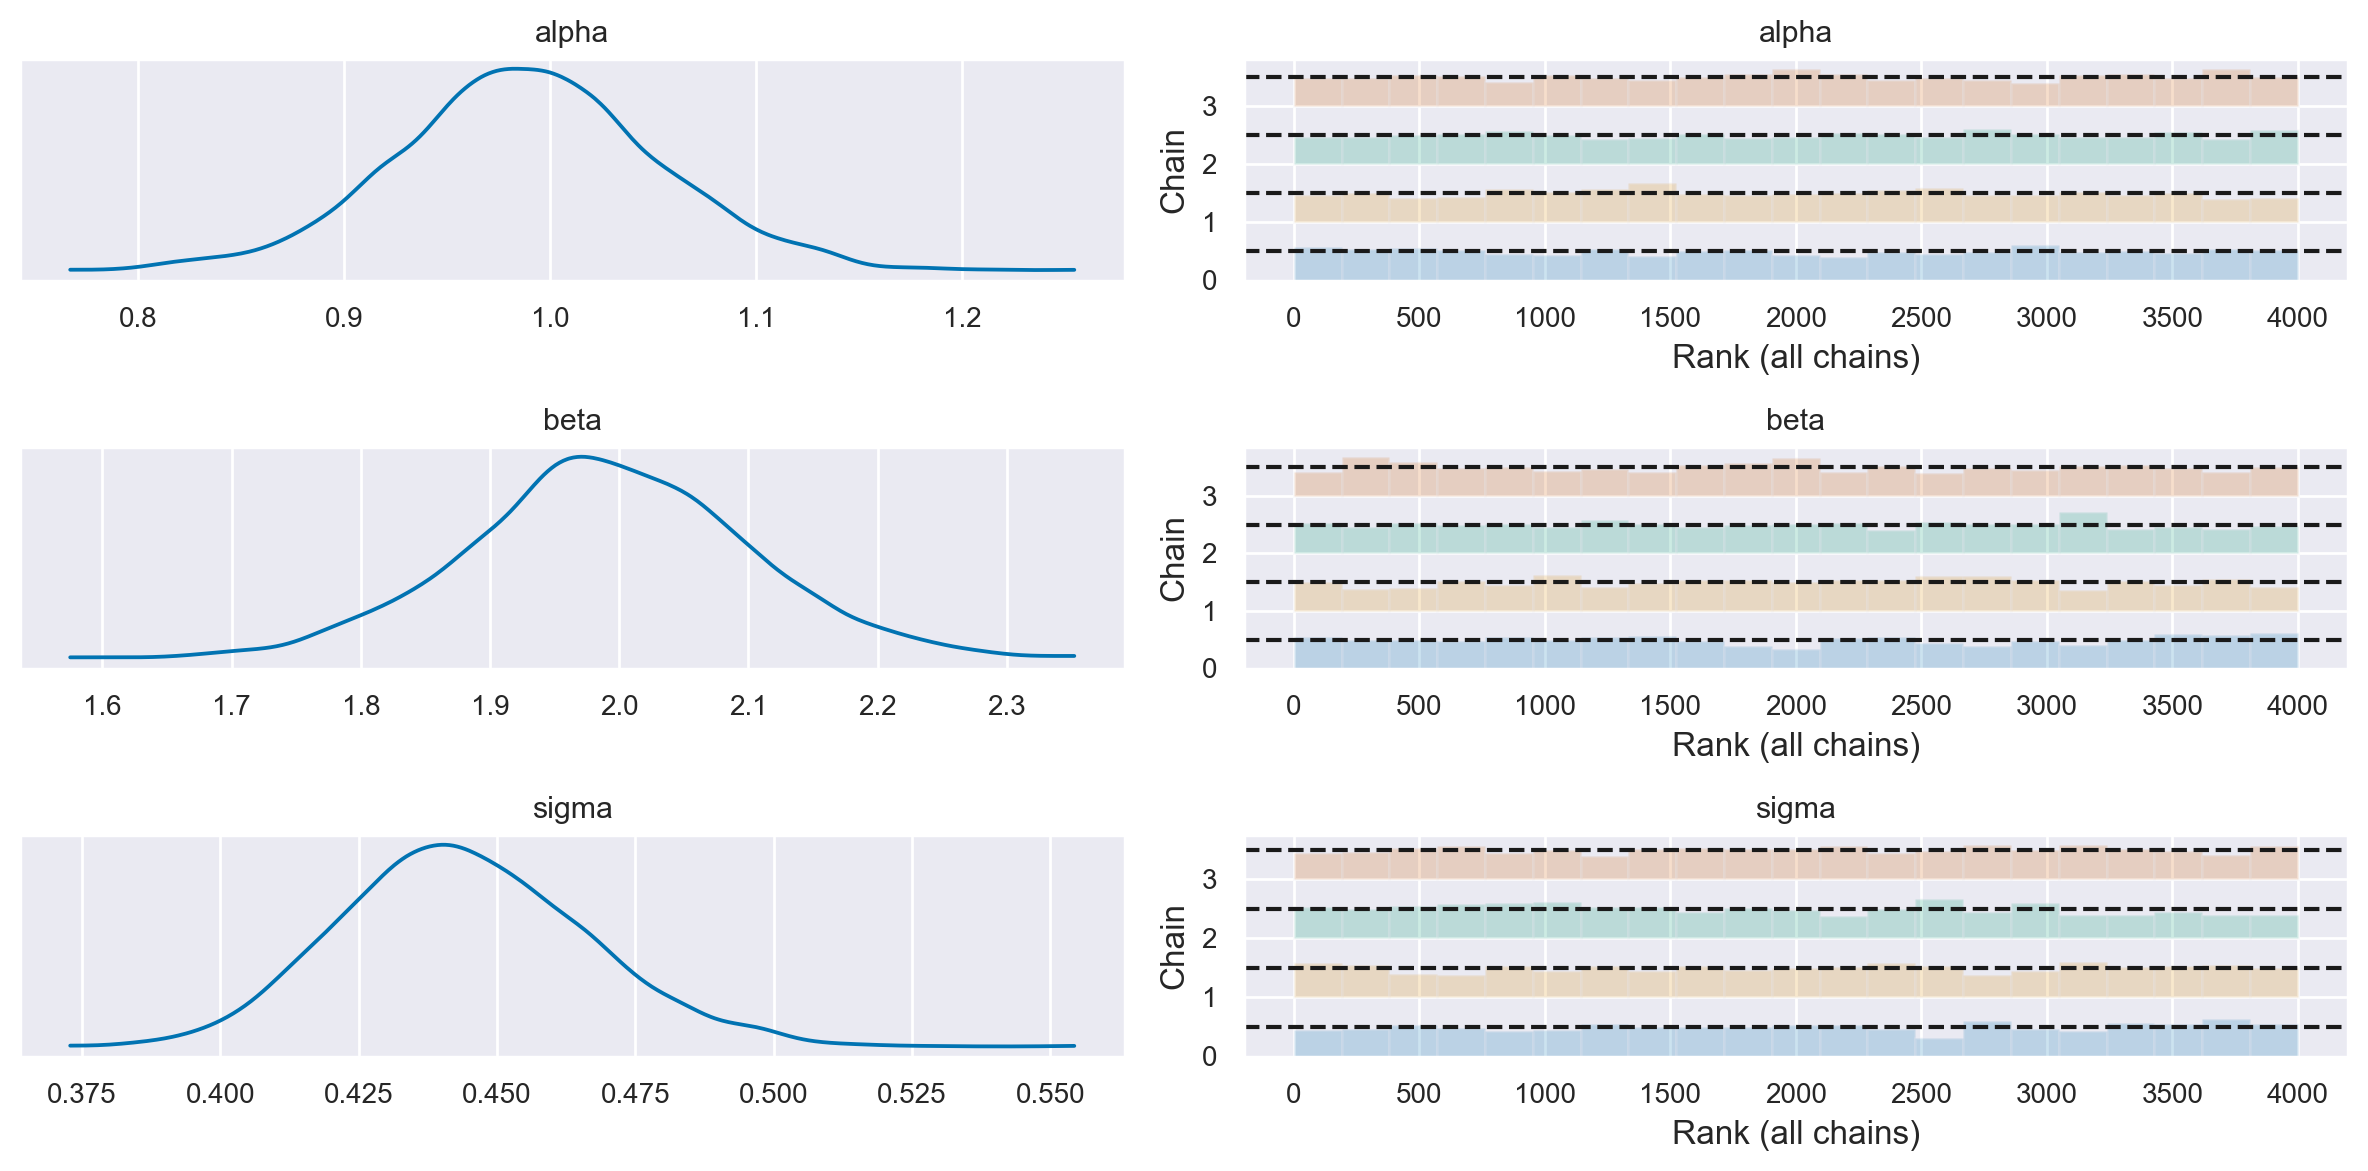

In [28]:
var_names = ["alpha", "beta", "sigma"]
az.plot_trace(idata, var_names=var_names, combined=True, kind="rank_bars")
plt.tight_layout()
plt.show()

In [29]:
params = ["alpha", "beta", "sigma"]
az.summary(idata, var_names = params, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.99,0.06,0.87,1.11,0.0,0.0,1905.06,1956.62,1.0
beta,1.99,0.11,1.78,2.20,0.0,0.0,1860.47,1933.28,1.0
sigma,0.44,0.02,0.40,0.48,0.0,0.0,2097.26,1791.52,1.0


In [30]:
idata.posterior['alpha']

<xarray.DataArray 'alpha' (chain: 4, draw: 1000)>
array([[1.0346396 , 0.97481813, 1.0325388 , ..., 0.9419452 , 1.04906417,
        0.96558743],
       [0.93819772, 1.01215996, 0.95441455, ..., 1.02185888, 0.9956501 ,
        0.9643339 ],
       [0.99239548, 0.94764794, 1.02666727, ..., 0.86549976, 0.84332208,
        0.96285164],
       [1.01637511, 0.98424915, 0.97923395, ..., 0.98670323, 1.02279363,
        0.96491527]])
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 992 993 994 995 996 997 998 999

In [31]:
alpha_array = idata.posterior['alpha'].values
beta_array = idata.posterior['beta'].values

print("Shape of alpha_array:", alpha_array.shape)
print("Shape of beta_array:", beta_array.shape) 

Shape of alpha_array: (4, 1000)
Shape of beta_array: (4, 1000)


In [32]:
# Flatten the 2D arrays into 1D arrays
alpha_flat = alpha_array.ravel()
beta_flat = beta_array.ravel()

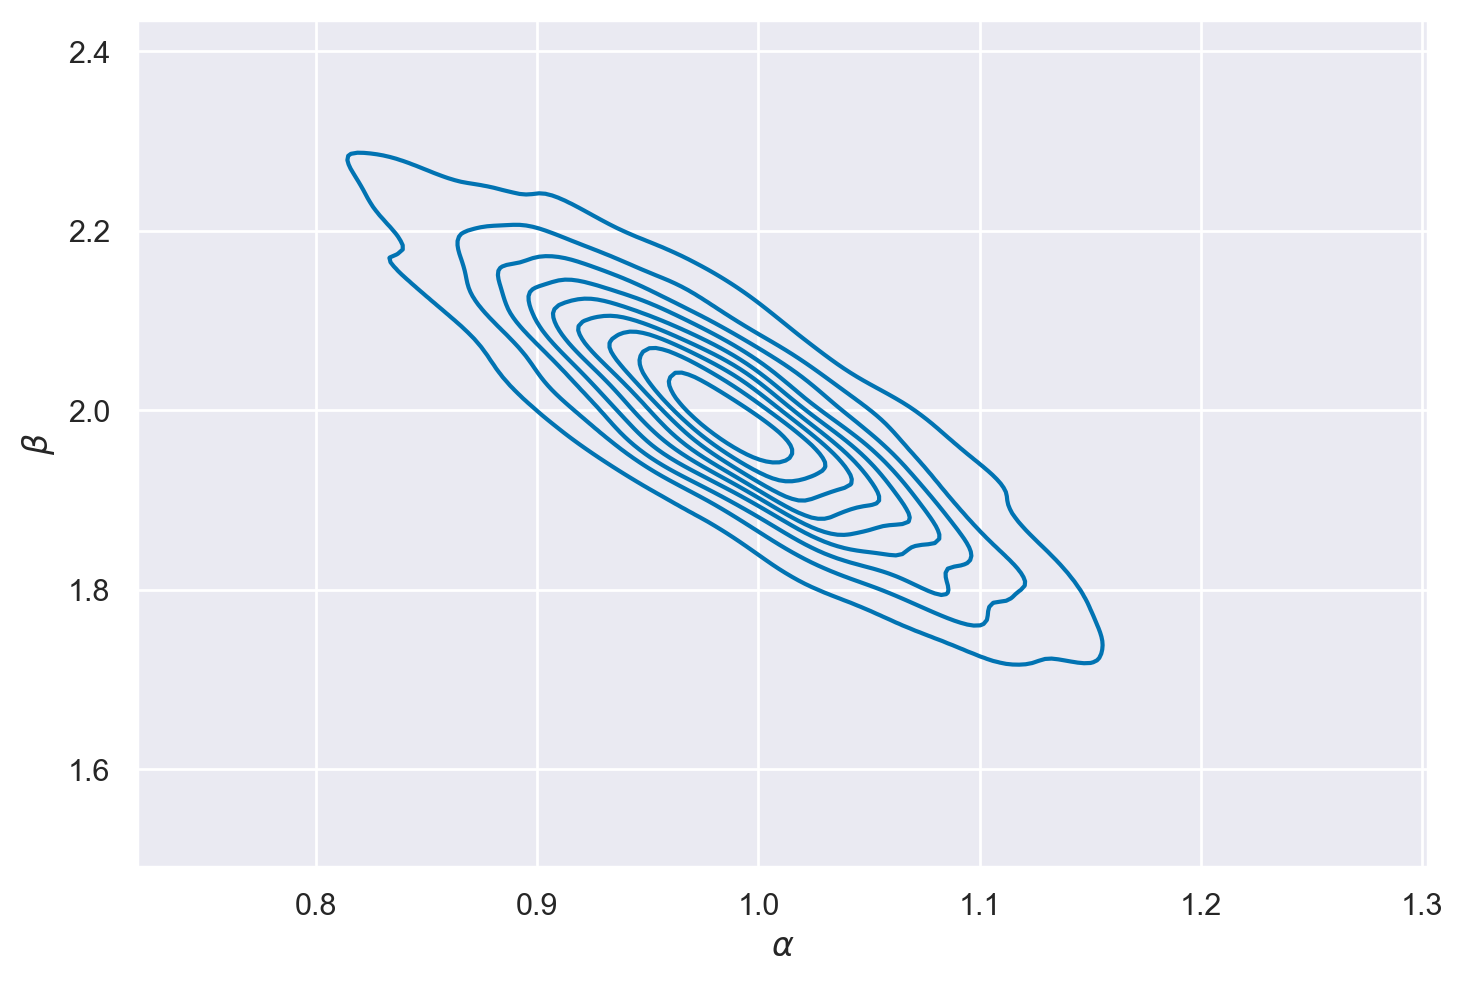

In [33]:
# Create the KDE plot
sns.kdeplot(x=alpha_flat, y=beta_flat)
plt.xlabel("$\\alpha$")
plt.ylabel("$\\beta$")
plt.show()

In [34]:
with model:
    prior_samples = pm.sample_prior_predictive(100)

Sampling: [alpha, beta, sigma, y_obs]


In [35]:
prior = prior_samples.prior
prior

<xarray.Dataset>
Dimensions:  (chain: 1, draw: 100)
Coordinates:
  * chain    (chain) int64 0
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 9 ... 90 91 92 93 94 95 96 97 98 99
Data variables:
    beta     (chain, draw) float64 0.5792 -0.001452 1.111 ... -2.05 -0.734 1.19
    alpha    (chain, draw) float64 -0.2922 -1.217 0.7468 ... -1.807 -0.5097
    sigma    (chain, draw) float64 0.6142 5.139 6.983 ... 3.089 11.68 0.4843
Attributes:
    created_at:                 2024-02-06T12:32:43.261975
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3

In [36]:
x = xr.DataArray(np.linspace(0, 1, 50))
x

<xarray.DataArray (dim_0: 50)>
array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
       0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
       0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.3877551 ,
       0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
       0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
       0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
       0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
       0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
       0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ])
Dimensions without coordinates: dim_0

In [37]:
np.array(az.extract_dataset(prior_samples["prior"])["alpha"][:50])

array([-0.29219538, -1.21663572,  0.74676339, -0.72389861,  0.34264543,
       -0.79927469, -0.93952745, -0.94770127,  0.23793045, -0.07646118,
       -2.14373297,  0.05211149,  1.51861963,  0.42724434, -1.63860446,
        0.41933053, -0.30916055, -1.2501237 ,  0.82375512,  0.01109213,
       -1.64033694,  0.55745022, -0.33837281,  0.05194841,  0.32291963,
        1.495507  ,  1.58557406, -0.76402067, -1.47731169, -1.44328034,
       -0.8069756 ,  1.51707556,  0.46784259,  0.28640835, -0.3749852 ,
       -1.0760841 , -0.04233802,  1.07753097, -1.70582396, -0.27609627,
       -1.12495299,  1.8766709 ,  0.79953061,  0.35128796,  0.22345423,
       -0.73944124, -1.27701544, -0.17015434, -0.84240845, -0.72774309])

In [38]:
np.array(az.extract_dataset(prior_samples["prior"])["beta"][:50])

array([ 5.79190645e-01, -1.45230935e-03,  1.11055796e+00,  1.11189159e+00,
        1.14542133e+00,  1.74380536e+00, -1.09653748e+00, -8.33443636e-01,
       -8.88020926e-01,  6.28443443e-02,  1.01461499e+00,  2.55617722e-01,
       -2.72461824e-01, -4.58024785e-01,  1.38563532e+00, -8.87817298e-01,
       -1.76620926e+00,  1.38266945e+00,  8.32017741e-01, -1.02240419e+00,
        3.50957706e-01, -1.90729972e+00,  3.65667908e-01, -1.15805017e+00,
        6.34406140e-01,  2.68565895e-01,  2.35624526e-01, -7.63781503e-01,
       -8.26588440e-01, -1.02345158e+00, -1.68256078e-04, -6.51840053e-01,
       -8.38329931e-01,  9.73158757e-01, -3.90918750e-02,  7.28958924e-01,
       -1.25848676e+00, -6.76077923e-01,  3.12005892e-01,  1.64416861e+00,
        1.49760449e+00,  6.76773568e-01, -1.40205720e+00,  4.08741856e-01,
        1.76270092e-01, -4.18083171e-01, -2.75764043e-01, -1.65921886e+00,
       -1.95837385e+00,  8.31328981e-01])

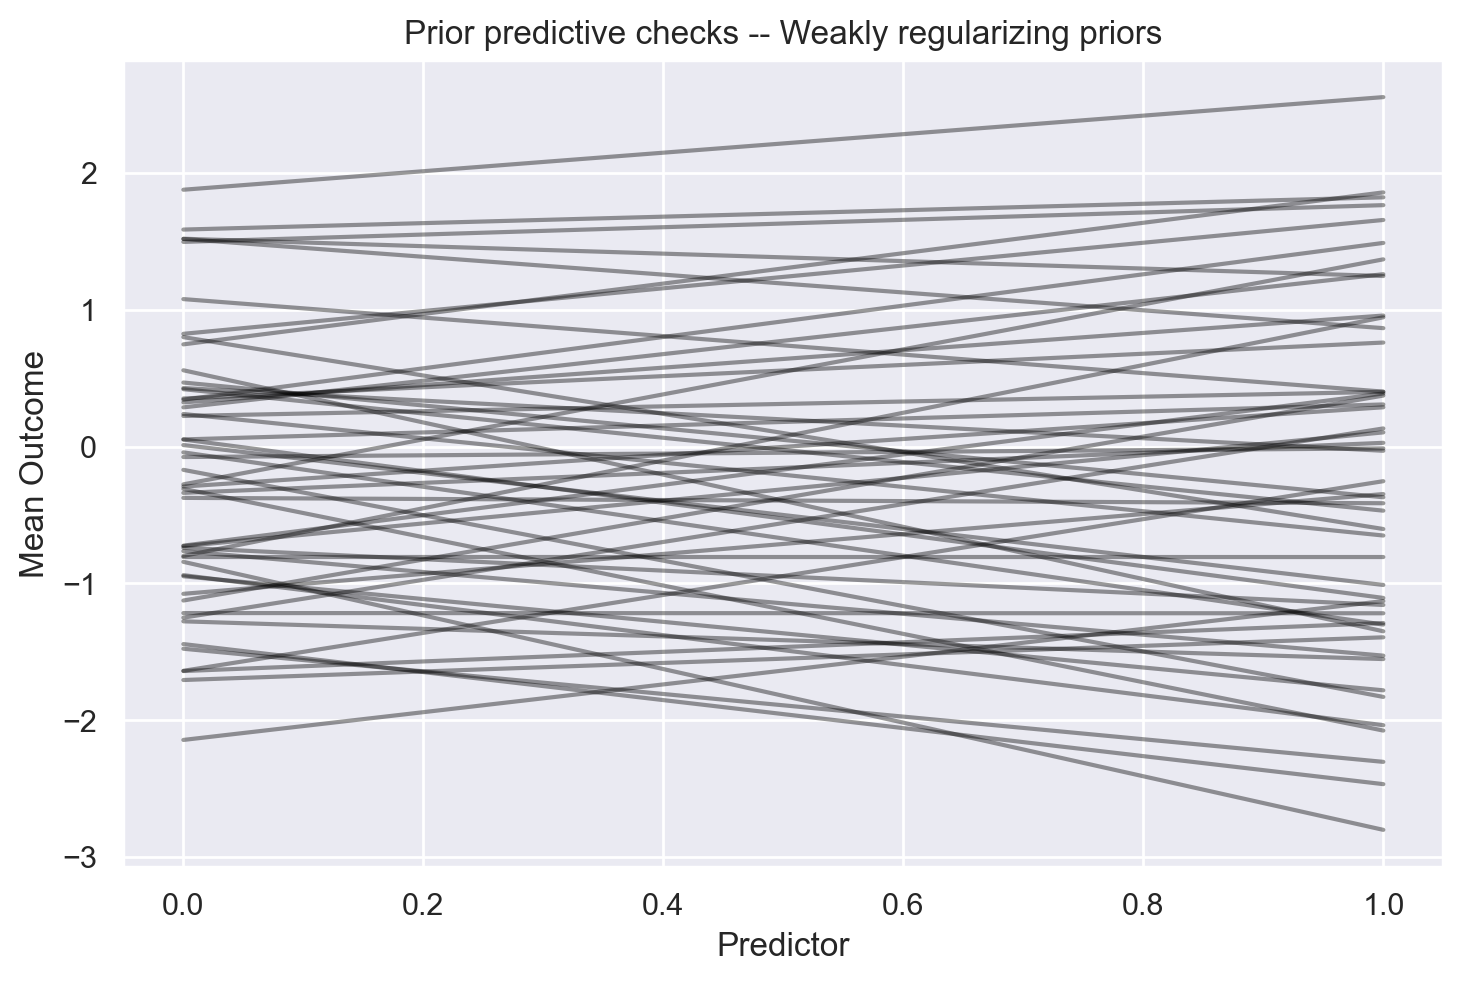

In [39]:
prior_samp_alpha = np.array(az.extract_dataset(prior_samples["prior"])["alpha"][:50])
prior_samp_beta = np.array(az.extract_dataset(prior_samples["prior"])["beta"][:50])

# Plotting the prior samples
for alpha, beta in zip(prior_samp_alpha, prior_samp_beta):
    y = alpha + beta * x
    plt.plot(x, y, c="black", alpha=0.4)

# Setting labels and title
plt.xlabel("Predictor")
plt.ylabel("Mean Outcome")
plt.title("Prior predictive checks -- Weakly regularizing priors")
plt.show()

In [40]:
with model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=True, random_seed=rng);

Sampling: [y_obs]


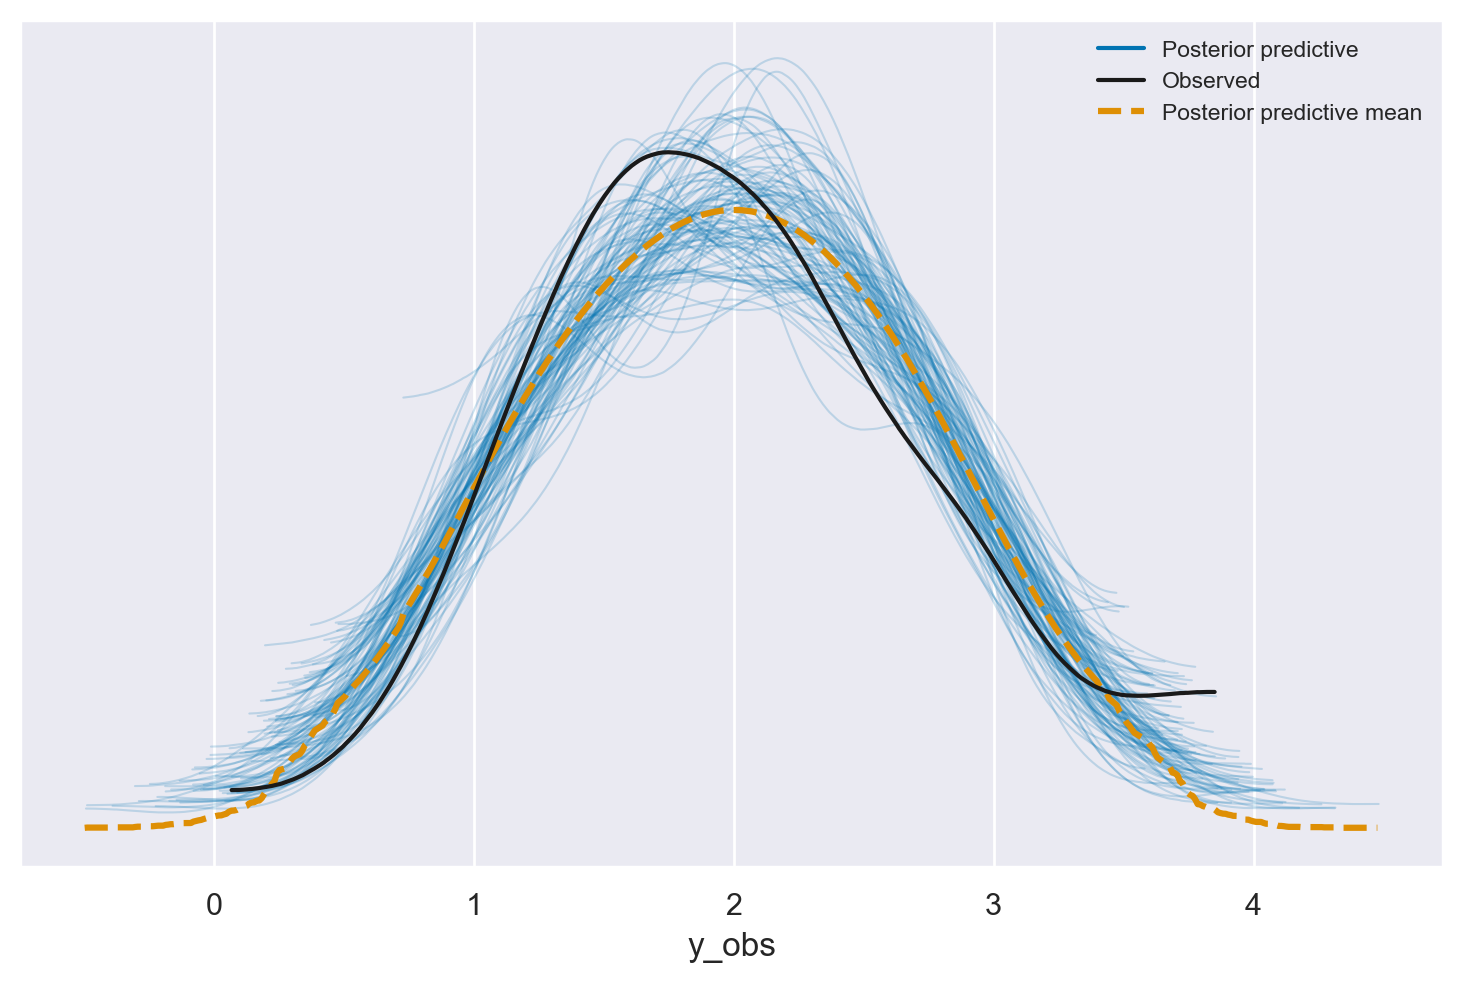

In [41]:
az.plot_ppc(idata, num_pp_samples=100)
plt.show()

In [42]:
%load_ext watermark
%watermark -n -u -v -iv -w -m

Last updated: Tue Feb 06 2024

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.19.0

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

xarray    : 2023.12.0
pandas    : 2.1.4
pymc      : 5.10.3
numpy     : 1.26.2
scipy     : 1.11.4
seaborn   : 0.13.0
arviz     : 0.17.0
matplotlib: 3.8.2

Watermark: 2.4.3

